In [1]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    'sales':[100,150,200,300,5000,700,3000,1500,400,600]
}
)
print(df.describe())

             sales
count    10.000000
mean   1195.000000
std    1603.546417
min     100.000000
25%     225.000000
50%     500.000000
75%    1300.000000
max    5000.000000


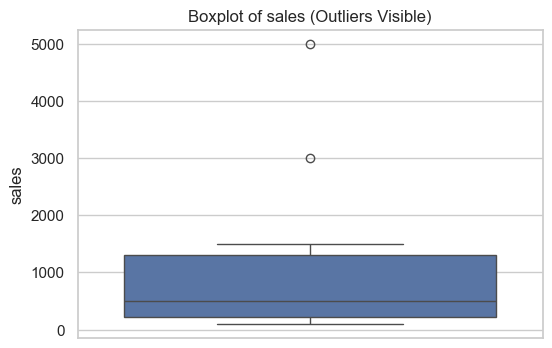

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

plt.figure(figsize=(6,4))

sns.boxplot(y=df['sales'])

plt.title("Boxplot of sales (Outliers Visible)")

plt.show()

In [3]:
#Removing mehtods 
#1:clipping 
df['sales_clipping'] = df['sales'].clip(upper=1000)
print(df)

   sales  sales_clipping
0    100             100
1    150             150
2    200             200
3    300             300
4   5000            1000
5    700             700
6   3000            1000
7   1500            1000
8    400             400
9    600             600


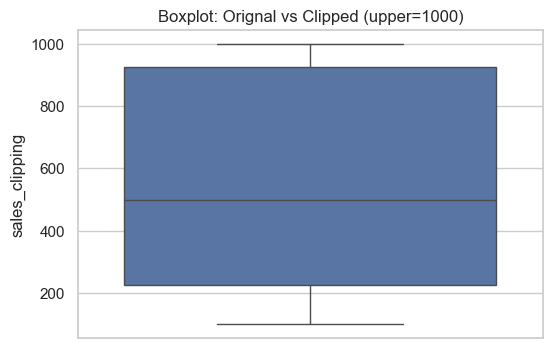

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

plt.figure(figsize=(6,4))

sns.boxplot(y=df['sales_clipping'])

plt.title("Boxplot: Orignal vs Clipped (upper=1000)")

plt.show()

In [6]:
#2: Winsorization
#top 20% capped 
from scipy.stats.mstats import winsorize

df['sales_winsorize'] = winsorize(df['sales'], limits=[0,0.2])
print(df)

   sales  sales_clipping  sales_winsorize
0    100             100              100
1    150             150              150
2    200             200              200
3    300             300              300
4   5000            1000             1500
5    700             700              700
6   3000            1000             1500
7   1500            1000             1500
8    400             400              400
9    600             600              600


In [7]:
#Removal drop outliers > 1000
df['sales_removed'] = df['sales'].where(df['sales']<=1000 , np.nan)
print(df)

   sales  sales_clipping  sales_winsorize  sales_removed
0    100             100              100          100.0
1    150             150              150          150.0
2    200             200              200          200.0
3    300             300              300          300.0
4   5000            1000             1500            NaN
5    700             700              700          700.0
6   3000            1000             1500            NaN
7   1500            1000             1500            NaN
8    400             400              400          400.0
9    600             600              600          600.0


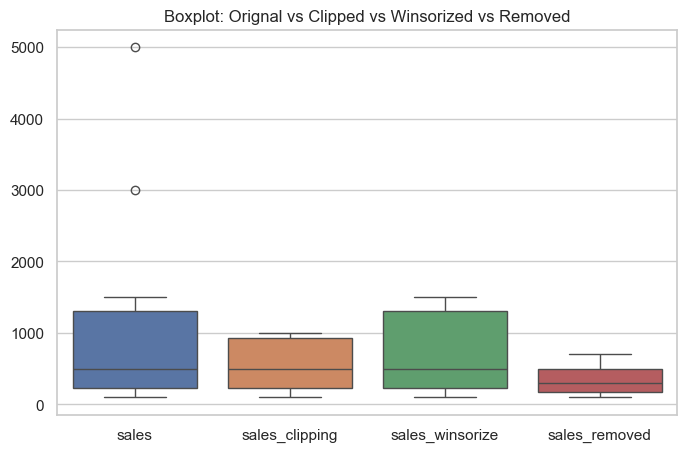

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style='whitegrid')

plt.figure(figsize=(8,5))

sns.boxplot(data=df[['sales','sales_clipping','sales_winsorize','sales_removed']])

plt.title("Boxplot: Orignal vs Clipped vs Winsorized vs Removed")

plt.show()